# Project: Data-driven Insights using Python: FoodHub Data Analysis



# Problem Statement

## Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. An online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub, offers access to multiple restaurants through a single smartphone app.
The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirm the pick-up in the app and travel to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



## Objective

The food aggregator company has stored the data of the different orders made by the registered customers in its online portal. They want to analyze the data to get a fair idea about the demand for different restaurants, which will help them enhance their customer experience. Suppose you are hired as a Data Scientist in this company, and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

## Data Description

The data contains different data related to a food order. The detailed data dictionary is given below.

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

# Let us start by importing the required libraries

In [18]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

ERROR: Ignored the following versions that require a different python version: 1.25.0 Requires-Python >=3.9; 1.25.1 Requires-Python >=3.9; 1.25.2 Requires-Python >=3.9; 1.26.0 Requires-Python <3.13,>=3.9; 1.26.1 Requires-Python <3.13,>=3.9; 1.26.2 Requires-Python >=3.9; 1.26.3 Requires-Python >=3.9; 1.26.4 Requires-Python >=3.9; 2.0.0 Requires-Python >=3.9; 2.0.1 Requires-Python >=3.9; 2.0.2 Requires-Python >=3.9; 2.1.0 Requires-Python >=3.10; 2.1.1 Requires-Python >=3.10; 2.1.2 Requires-Python >=3.10; 2.1.3 Requires-Python >=3.10; 2.2.0 Requires-Python >=3.10; 2.2.1 Requires-Python >=3.10; 2.2.2 Requires-Python >=3.10; 2.2.3 Requires-Python >=3.10; 2.2.4 Requires-Python >=3.10; 2.2.5 Requires-Python >=3.10; 2.2.6 Requires-Python >=3.10; 2.3.0 Requires-Python >=3.11; 2.3.1 Requires-Python >=3.11; 2.3.2 Requires-Python >=3.11; 2.3.3 Requires-Python >=3.11; 2.3.4 Requires-Python >=3.11; 2.3.5 Requires-Python >=3.11; 2.4.0 Requires-Python >=3.11; 2.4.0rc1 Requires-Python >=3.11; 2.4.1 Req

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [4]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To suppress warnings 
import warnings
warnings.filterwarnings('ignore') 
plt.rcParams['font.family'] = 'DejaVu Sans'

# Understanding the structure of the data

In [22]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Write your code here to read the data
df = pd.read_csv('foodhub_order.csv')

In [6]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [26]:
# Write your code here
df.shape

(1898, 9)

#### Observations:
There are 1898 rows and 9 columns in the FoodHub dataset.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [29]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The dataset has 9 columns. order_id, customer_id, food_preparation_time and delivery_time are integer datatypes, restaurant_name,cuisine_type, day_of_the_week and rating are object(string) datatypes and cost_of_the_order is a float datatype.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [32]:
# Write your code here
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:
According to the dataset there are no missing values across all 9 columns.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [35]:
# Write your code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


The minimum time it takes for food to be prepared is 20 minutes while the maximum time it takes is 35 minutes. On average it takes approximately 27 minutes for the food to be prepared.

### **Question 5:** How many orders are not rated? [1 mark]

In [38]:
# Write the code here
df['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

In [39]:
(736/1898) *100 # This is the percentage of unrated orders

38.77766069546891

#### Observations:
Out of the 1898 orders, 736 orders were not rated , their ratings were recorded as Not given. This accounts for approximately 38.77% of all orders.


# Exploratory Data Analysis (EDA)

## Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

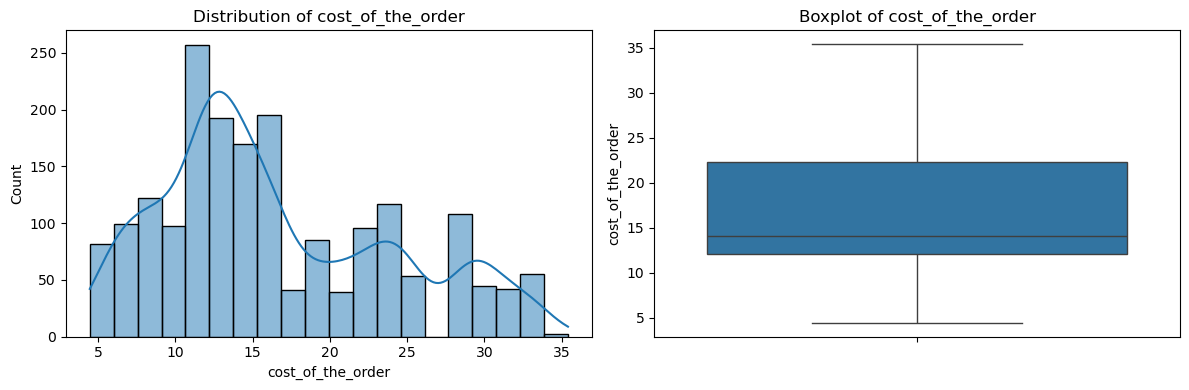

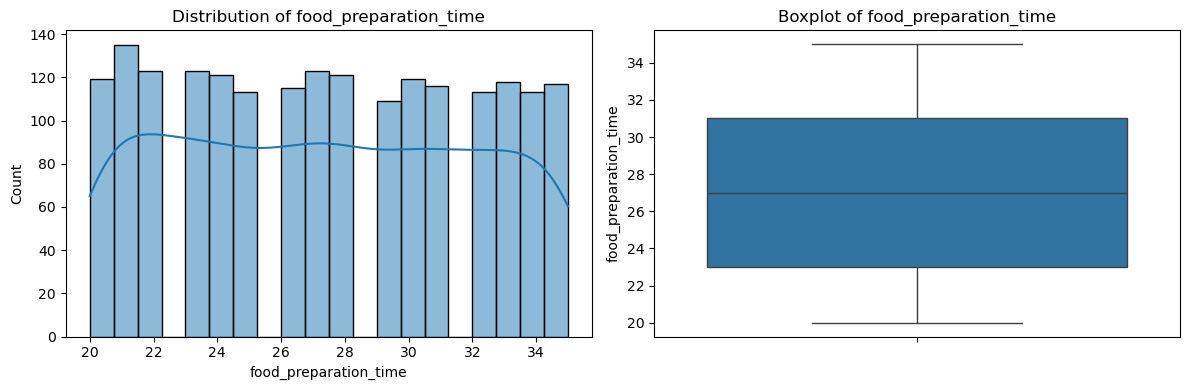

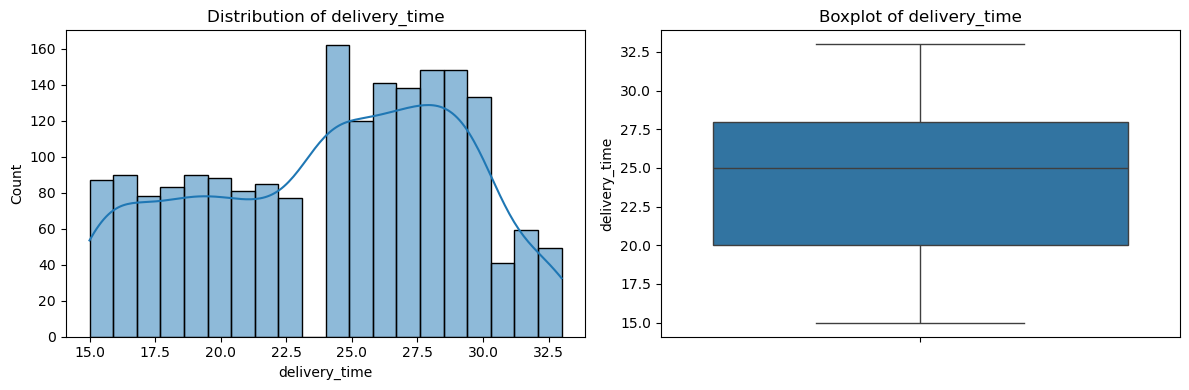

In [54]:
# Write the code here
# Numerical columns list  # Histograms and boxplot for each numerical columns
numerical_columns =['cost_of_the_order','food_preparation_time','delivery_time']

for col in numerical_columns:
    fig, axes = plt.subplots(1,2 ,figsize =(12,4)) # creates a 2 sides plot for each column
    
# Histogram plot 
    sns.histplot(df[col], bins =20, kde = True, ax= axes[0]) # kde =true adds a smooth density curve 
    axes[0].set_title(f'Distribution of {col}')
# Box plot # Boxplot helps identify outliers and spread of data
    sns.boxplot(df[col], ax =axes [1])
    axes[1].set_title(f'Boxplot of {col}');
    plt.tight_layout()  # prevents the plot from overlapping
    plt.show()


#### Observations:

* The distribution of cost_of_the_order is right-skewed which implies that most orders are concentrated at lower price ranges approximately between 10 and 15 while fewer orders have higher cost.The box plot of cost_of_the_order shows a wide spread in data with the maximum values extending higher than the median. There are no outliers.
  
* The distribution of food_preparation_time appears uniform and symmetric with values spreading approximately from 20 to 35 minutes.The boxplot indicates the median lies in the center of the distribution and there are no outliers.This suggests that consistent time for food preparation lies across orders.
  
* The distribution of delivery_time is slightly positively skewed most orders occur between 25 and 30 minutes. The boxplot shows a moderate spread with a median of 25. There are no outliers indicating delivery times are consistent.

* Overall, the numerical variables show moderate variability with minimal presence of outliers.
While cost_of_the_order exhibits a right-skewed distribution indicating occasional high-value orders, both food_preparation_time and delivery_time are relatively well-balanced, suggesting operational consistency in preparation and delivery processes.


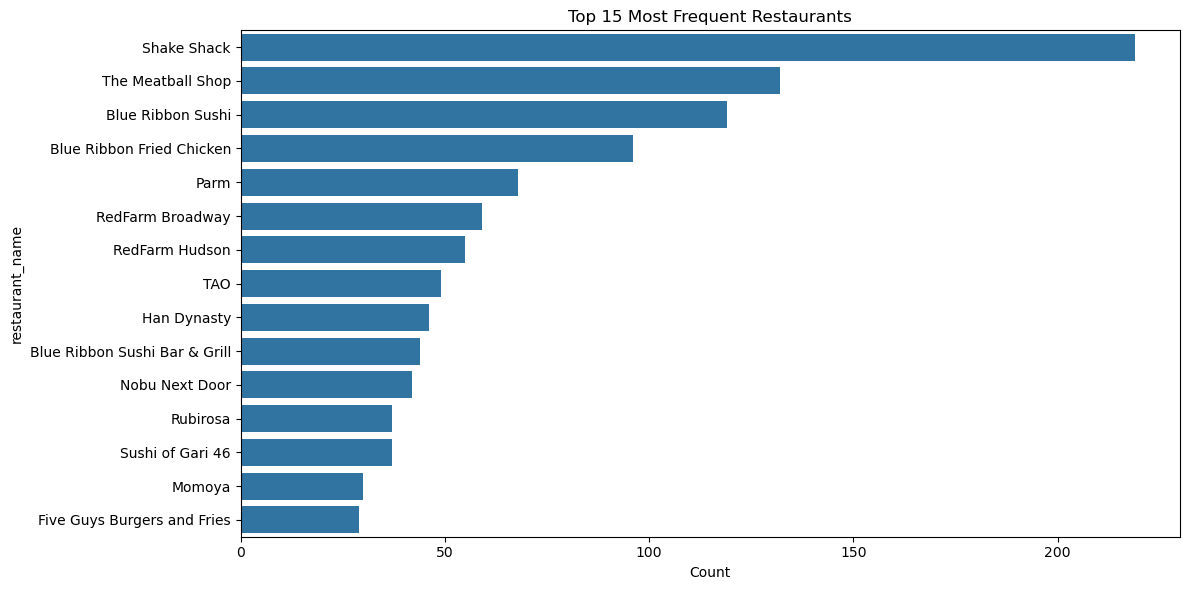

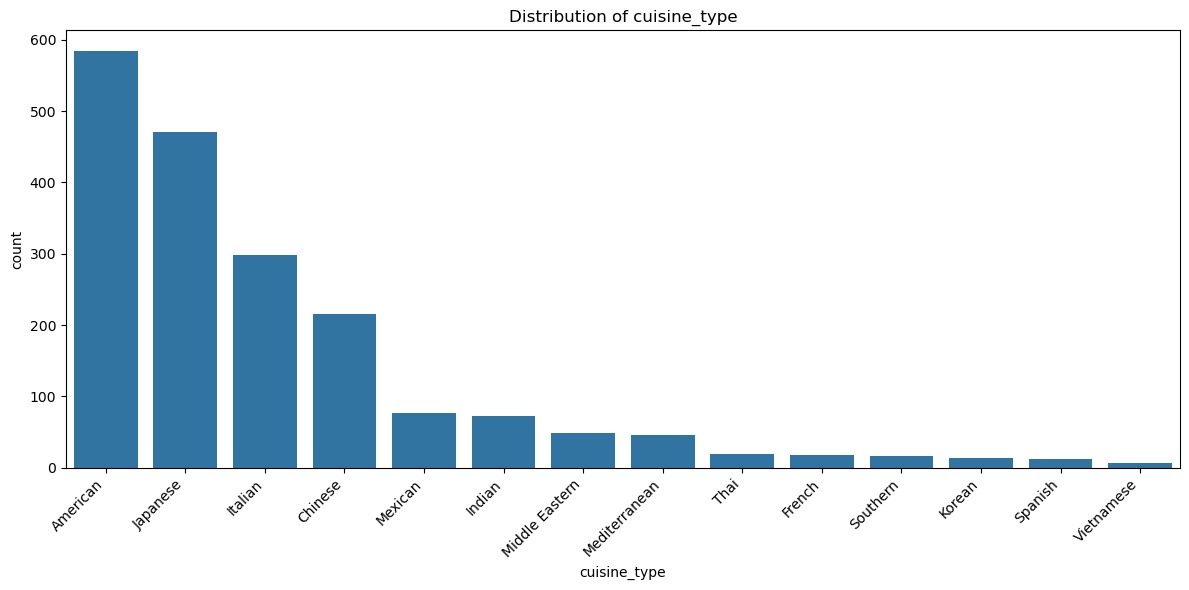

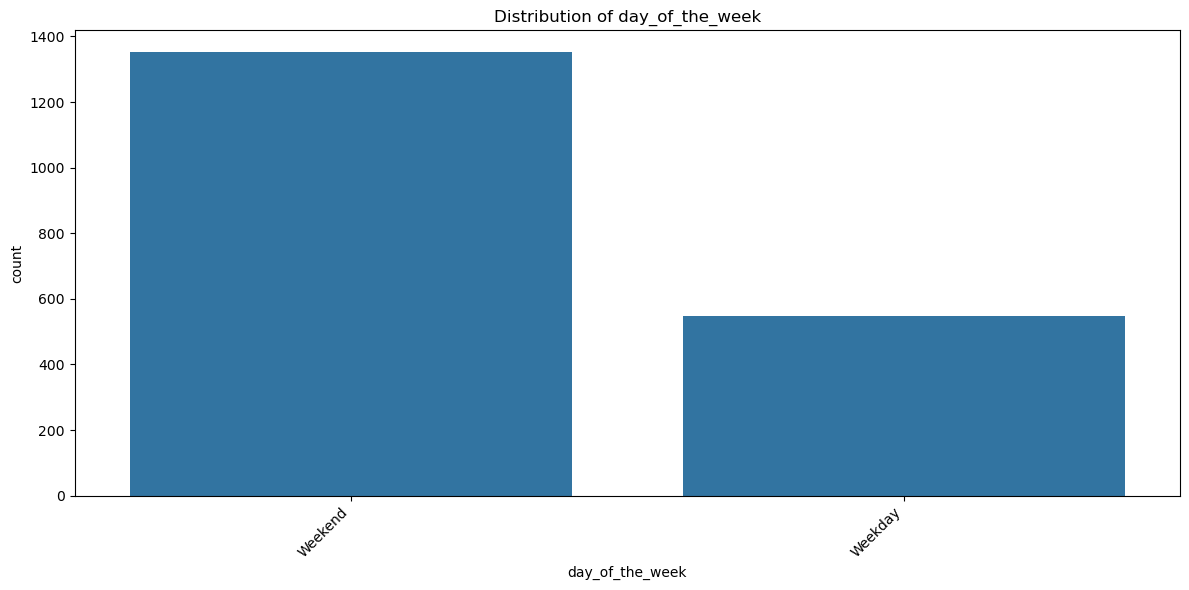

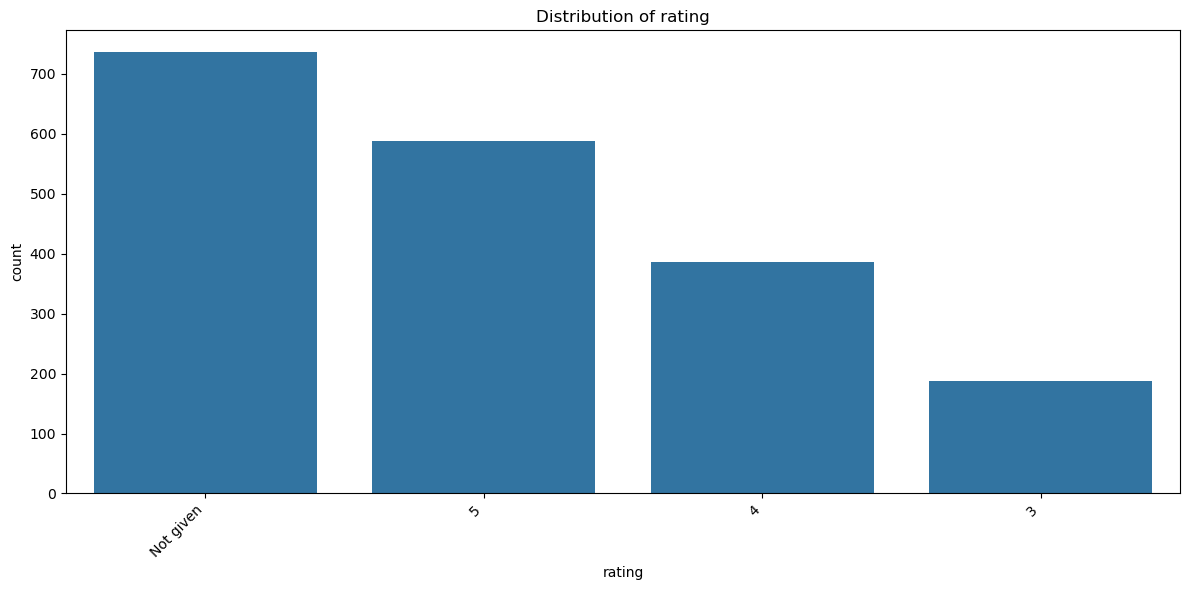

In [105]:
# Categorical column list 

plt.rcParams['font.family'] = 'DejaVu Sans'  # Fixes font glyph warning

# List of categorical columns
cat_cols = ['restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating']

for col in cat_cols:
    plt.figure(figsize=(12, 6))
    
    if col == 'restaurant_name':
        # Show only top 15 restaurants using horizontal bar chart for readability
        top_15 = df['restaurant_name'].value_counts().head(15)
        sns.barplot(x=top_15.values, y=top_15.index)
        plt.title('Top 15 Most Frequent Restaurants')
        plt.xlabel('Count')
        
    else:
        # Normal countplot for other categorical columns
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45, ha='right')  # ha='right' aligns labels neatly
    
    plt.tight_layout()
    plt.show()

#### Observations:

* Shake Shack, The Meatball Shop, Blue Ribbon Sushi and Blue Ribbon Fried Chicken are the most highly frequented restaurants, with Shake Shack leading at approximately 220 orders.
  
* American, Japanese, Italian and Chinese are the leading cuisines with counts ranging approximately from 215 to 580. Korean, Spanish and Vietnamese have the lowest counts.
  
* Orders tend to be significantly higher on weekends than weekdays, with weekend orders at approximately 1350 compared to weekday orders at approximately 550.
  
* The majority of registerd customers have not rated the service, with over 736 unrated orders. Among those who did rate, a rating of 5 was the most common at approximately 588, followed by 4 at approximately 386 and 3 at approximately 188.

* Overall, The categorical variables reveal several key patterns in the dataset. A few restaurants, particularly Shake Shack, dominate the orders suggesting strong customer preference for certain brands. American and Japanese cuisines are the most popular, reflecting the dining preferences of the customer base. The significantly higher volume of orders on weekends compared to weekdays suggests that customers tend to prefer food delivery as a leisure activity. Finally, the high number of unrated orders is notable, indicating that a large proportion of registered customers do not engage with the rating system. However, among those who do rate, the tendency towards higher ratings (4 and 5) suggests general customer satisfaction with the service.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [108]:
# Write the code here
Top5_restaurants = df['restaurant_name'].value_counts().head(5)
Top5_restaurants

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
The top 5 restaurants in terms of orders that they received are Shake Shack (226 orders), The Meatball Shop (132 orders), Blue Ribbon Sushi (119 orders), Blue Ribbon Fried Chicken (96 orders) and Parm (68 orders)

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [111]:
# Write the code here
# Filter for weekend orders to get most popular cuisine
weekend_cuisine = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()
weekend_cuisine

cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Mediterranean      32
Middle Eastern     32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64

#### Observations:

* American cuisine is the most popular cuisine ordered on the weekends with a count of 415 orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [114]:
# Write the code here
# percentage of orders that cost more than 20 dollars
orders_above_20 = df[df['cost_of_the_order'] > 20]['cost_of_the_order'].count()
percentage = (orders_above_20 / df.shape[0]) * 100 # df.shape[0] gives the rows 
print(f'Percentage of orders above $20: {percentage:.2f}%') # percentage :.2f is rounding off to 2 decimal places

Percentage of orders above $20: 29.24%


#### Observations:
Approximately 29.24% of orders cost more than 20 dollars, implying that the majority of customers tend to spend less than 20 dollars when ordering their food.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [119]:
# Write the code here
# calculates the mean of delivery time
mean_delivery_time = df['delivery_time'].mean()
print(f'The mean order delivery time is :{mean_delivery_time:.2f}')  # rounds of mean to 2 decimal places

The mean order delivery time is :24.16


#### Observations:
The mean delivery time for orders is 24.16 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [122]:
# Write the code here
# Top 5 most frequent customers by number of orders
top_5_customers = df['customer_id'].value_counts().head(5)
top_5_customers

customer_id
52832     13
47440     10
83287      9
250494     8
259341     7
Name: count, dtype: int64

#### Observations:
The top 5 customer IDs who will receive a 20% discount vouchers are 52832(13 orders),47440(10 orders),83287(9 orders),250494(8 orders) and 259341(7 orders). Customer 52832 leads with the highest number of orders.

## Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset and provide observations. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


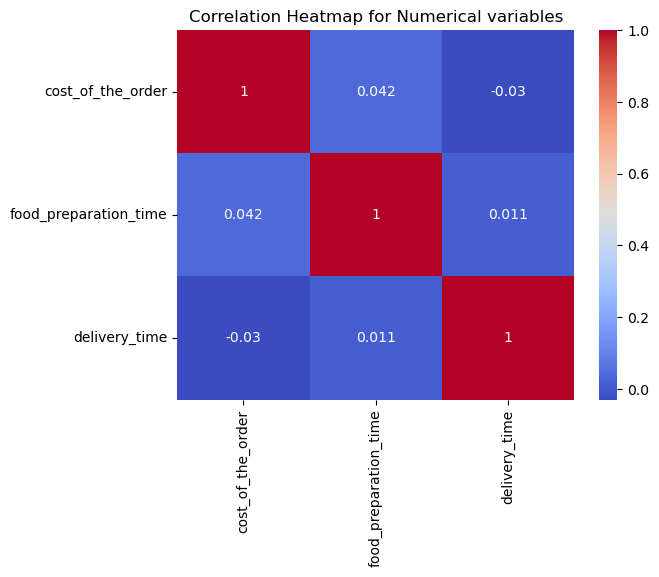

In [10]:
# Write the code here
# Numerical vs Numerical - Correlation Heatmap
num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Numerical variables")
plt.show()

#### Observations:
The correlation shows that there's no strong relationship between the variables. Cost_of_the_order and food_preparation_time has a correlation of 0.042 which is a weak positive correlation while cost_of_the_order and delivery_time have a weak negative correlation of -0.03. food_prepation_time and delivery_time has a correlation of 0.011. This implies that the numerical variables are independent of each other.


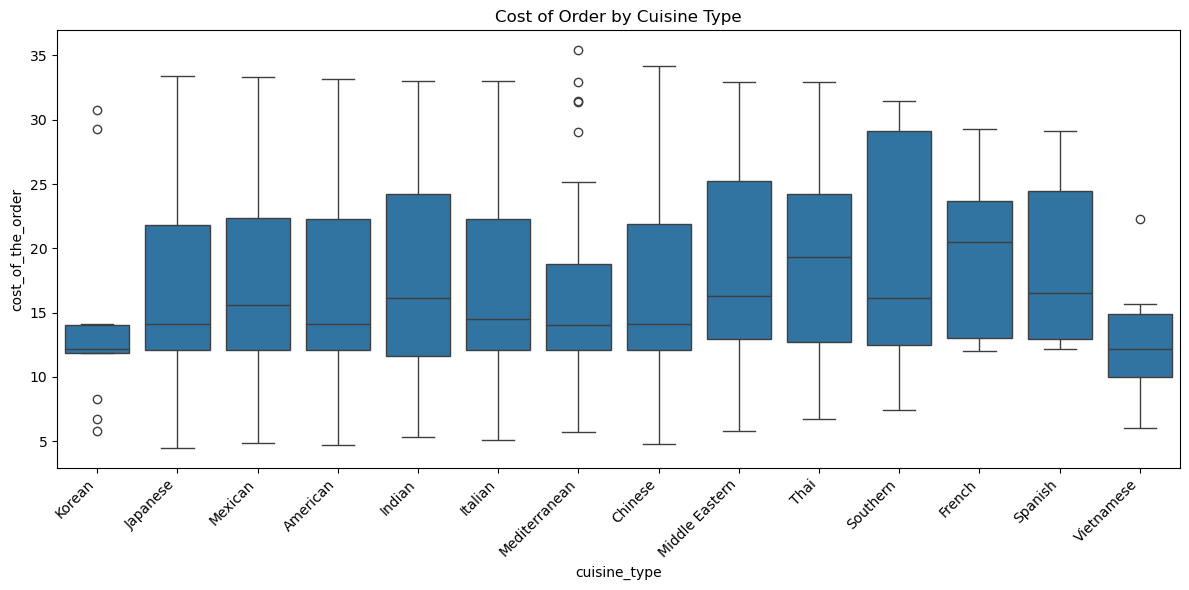

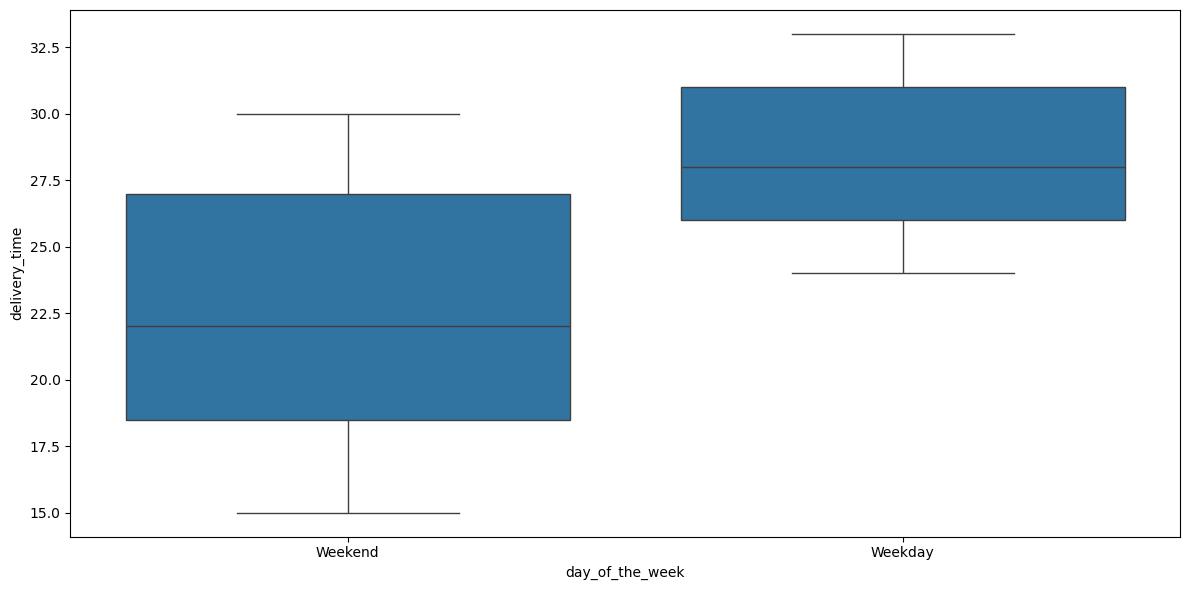

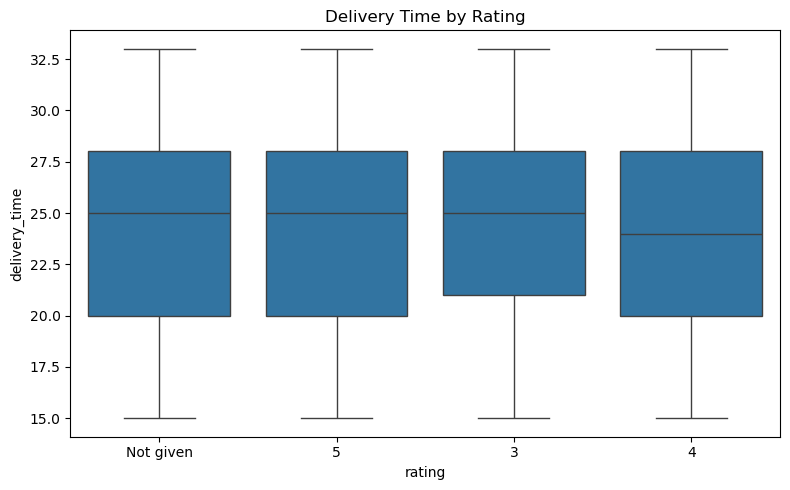

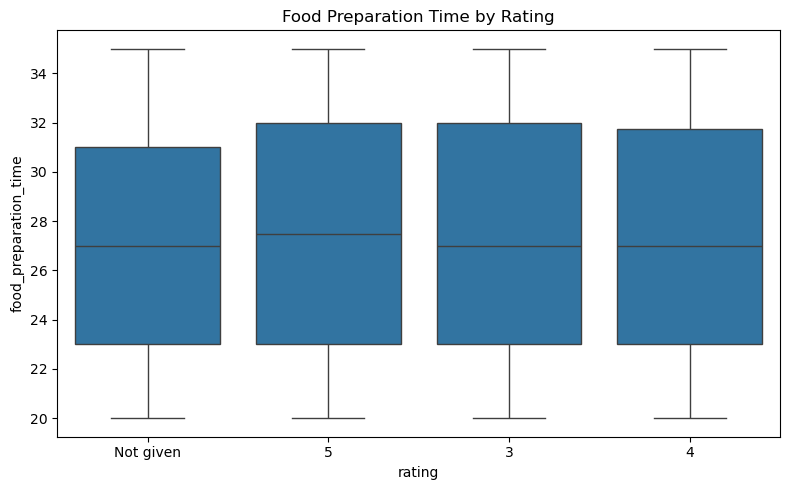

In [24]:
# Numerical vs Categorical relationship

# Cost of order by cuisine type
plt.figure(figsize=(12, 6))  # Wide figure to accommodate many cuisine types
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')  # Boxplot to show cost distribution per cuisine
plt.title('Cost of Order by Cuisine Type')
plt.xticks(rotation=45, ha='right')  # prevent overlapping by rotating labels
plt.tight_layout()
plt.show()

# Day of the week by delivery time
plt.figure(figsize=(12, 6))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)  # Compare delivery time between weekend and weekday
plt.title('Delivery Time by Day of the Week')  
plt.tight_layout()
plt.show()

# Delivery time by rating
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='rating', y='delivery_time')  # Explore if delivery time influences customer rating
plt.title('Delivery Time by Rating')
plt.tight_layout()
plt.show()

# Food preparation time by rating
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='rating', y='food_preparation_time')  # Explore if prep time influences customer rating
plt.title('Food Preparation Time by Rating')
plt.tight_layout()
plt.show()

#### Observations:
* For the cost_of_the_order by Cuisine type it shows outliers in the Korean, Meditereranean and Vietnamese cuisines.Southern cuisine has the highest overall cost range with its box extending from approximately 19 to 29 dollars. Both Southern and French cuisines tend to be on the more expensive end compared to other cuisines like Korean and Vietnamese which have the lowest median costs.

* The box plot for day_of_the_week by delivery_time shows weekdays take significantly longer than weekend deliveries. The median delivery time on weekdays is approximately 28 minutes compared to 22 minutes on weekends. Weekday deliveries also show a narrower spread ranging from approximately 24 to 31 minutes, while weekend deliveries have a wider spread ranging from approximately 18 to 27 minutes. This suggests that deliveries are faster and more variable on weekends while weekday deliveries are slower but more consistent.

* The boxplot of delivery_time by rating shows that delivery time has little to no impact on customer ratings. All rating categories including Not given, 3, 4 and 5 have a very similar median delivery time of approximately 24 to 25 minutes and almost identical spreads. This suggests that customers do not necessarily give lower ratings due to longer delivery times. The consistency across all rating groups indicates that other factors such as food quality or order accuracy may influence customer ratings more than delivery time.

* The food_preparation_time by Rating boxplot shows there's no influence on customer ratings to food_preparation time. All rating categories including Not given, 3, 4 and 5 have a very similar median preparation time of approximately 27 minutes with almost identical spreads ranging from approximately 23 to 32 minutes. No outliers are present across any rating group. 


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [37]:
# Write the code here
# filter out Not given in Rating column and convert to numeric 
df = df[df['rating'] != 'Not given']
df['rating'] = df['rating'].astype(float)
# Group by Restaurant name and calculate rating count and average rating 
restaurant_rating = df.groupby('restaurant_name')['rating'].agg(rating_count ='count',average_rating='mean').reset_index() # reset _index coverts grouped column into a regular column and gives a default index

# filters restaurant rating count >50 and average rating >4
restaurant_promo_offer = restaurant_rating[(restaurant_rating['rating_count'] > 50)&(restaurant_rating['average_rating'] > 4)]
restaurant_promo_offer

,restaurant_name,rating_count,average_rating
16,Blue Ribbon Fried Chicken,64,4.328125
17,Blue Ribbon Sushi,73,4.219178
117,Shake Shack,133,4.278195
132,The Meatball Shop,84,4.511905


#### Observations:
* Blue Ribbon Fried Chicken, Blue Ribbon Sushi , Shake Shack and The Meatball Shop fit the criteria to be provided a promotional offer in the advertisement of their restaurant. Shake Shack is leading with a rating count of 133 and has an average rating of 4.27.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [46]:
# Write the code here
# defining function to calculate commision 
def net_revenue(cost):
    if cost > 20:
        return cost * 0.25 # 25% commission on orders greater than 20 dollars
    elif cost > 5:
        return cost * 0.15 # 15% commission on orders greater than 5 dollars
    else:
        return 0 
# Applying function to cost_of_the_order 
df['net_revenue']= df['cost_of_the_order'].apply(net_revenue) # apply function- applies a function to every row or column in a dataframe or series one at a time.

# Total revenue
total_revenue = df['net_revenue'].sum()
total_revenue

3865.572

The net revenue generated across all orders by the company is 3865.57 dollars.This was calculated by charging a commission of 25% on orders costing more than 20 dollars and 15% on orders costing more than 5 dollars. Given that approximately 29.24% of orders cost more than 20 dollars, implying that the majority of customers tend to spend less than 20 dollars when ordering their food. This implies that the bulk of the company's revenue is generated from the 15% commission tier.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [51]:
# Write the code here
# Calculate total time by adding food preparation time and delivery time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Count orders that take more than 60 minutes
orders_above_60 = df[df['total_time'] > 60]['total_time'].count()

# Calculate percentage
percentage_above_60 = (orders_above_60 / df.shape[0]) * 100  # df.shape[0] gives total rows

print(f'Percentage of orders taking more than 60 minutes: {percentage_above_60:.2f}%') # .2f gives output to 2 decimal places

majority_of_orders = 100 - 10.24 
print(majority_of_orders)

Percentage of orders taking more than 60 minutes: 10.24%
89.76


#### Observations:
The total time for an order is calculated by adding food preparation time and delivery time. 10.24% of orders take more than 60 minutes to be delivered from the time the order is placed, meaning the vast majority of orders (89.76%) are delivered within 60 minutes

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [59]:
# Write the code here
# Calculate mean delivery time for weekdays and weekends
mean_delivery = df.groupby('day_of_the_week')['delivery_time'].mean()  # Group by day and calculate mean

print(mean_delivery)
time_difference =  28.305882 -22.436740
print(f'Time difference is : {time_difference :.2f}') # .2f rounding of to 2 decimal places 

day_of_the_week
Weekday    28.305882
Weekend    22.436740
Name: delivery_time, dtype: float64
Time difference is : 5.87


#### Observations:
During weekdays the mean delivery time is 28.30 minutes while the weekends is 22.43 minutes. This shows that weekday deliveries take longer compared to weekends, with a difference of approximately 5.87 minutes.


# Conclusion and Business Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

## Conclusions

-  


## Business Recommendations

-  



---

